In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

In [33]:
iris = load_iris()

print("Iris dataset loaded successfully!")

Iris dataset loaded successfully!


In [34]:


print("Feature names:")
print(iris.feature_names)

print("\nTarget names:")
print(iris.target_names)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']


In [35]:
# Convert the dataset into a Pandas DataFrame

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add the target column
df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [36]:
# Convert numerical target values into species names

df["species"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [37]:
# Check dataset shape

print("Dataset shape:", df.shape)

Dataset shape: (150, 5)


In [38]:
# Check data types

print(df.dtypes)

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object


In [39]:
# Check for missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [40]:
# Display descriptive statistics

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [41]:
# Count the number of samples in each species

print(df["species"].value_counts())

species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


# 2. Data Visualization

Visualizations help us understand the relationships and distributions of the different flower measurements across the three iris species.

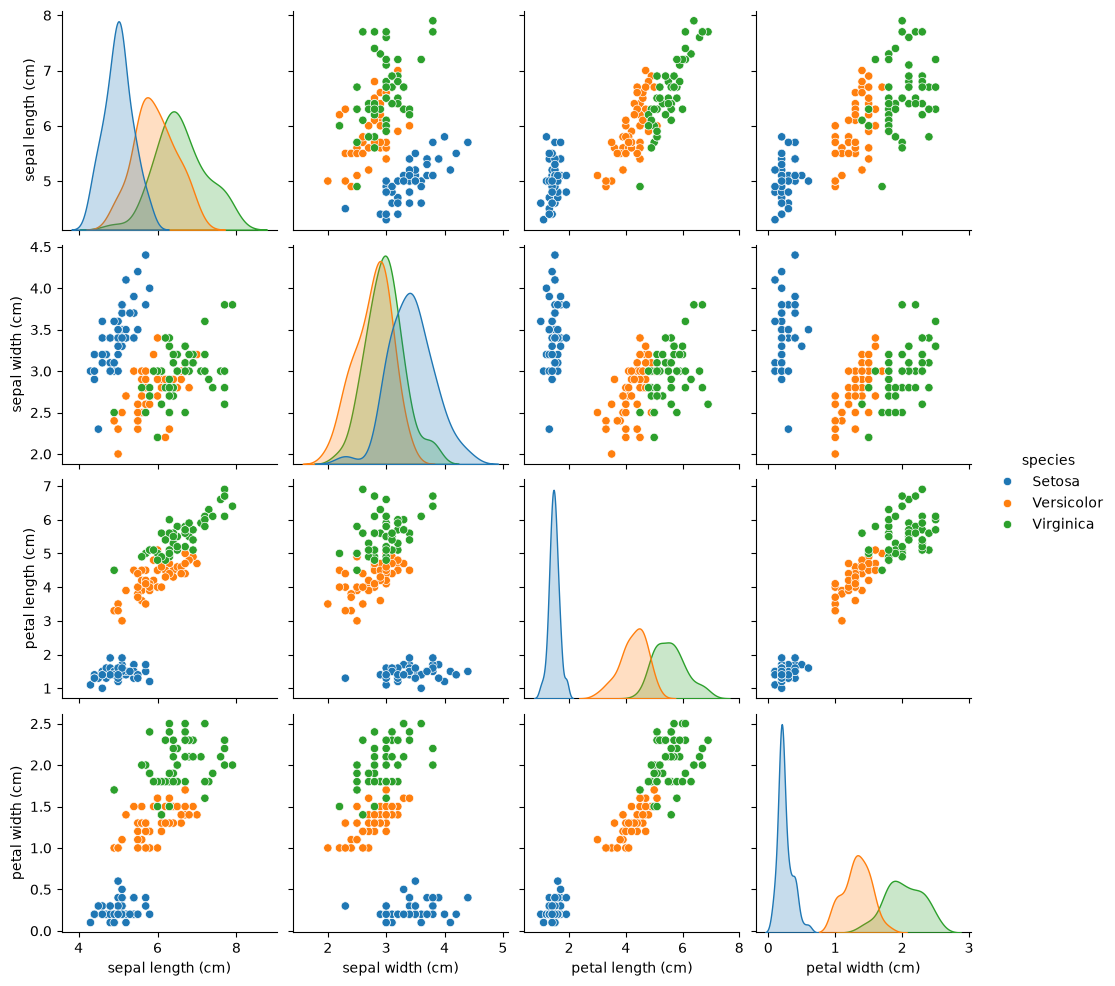

In [42]:
# Pairplot showing relationships between features by species

sns.pairplot(
    df,
    hue="species"
)

plt.show()

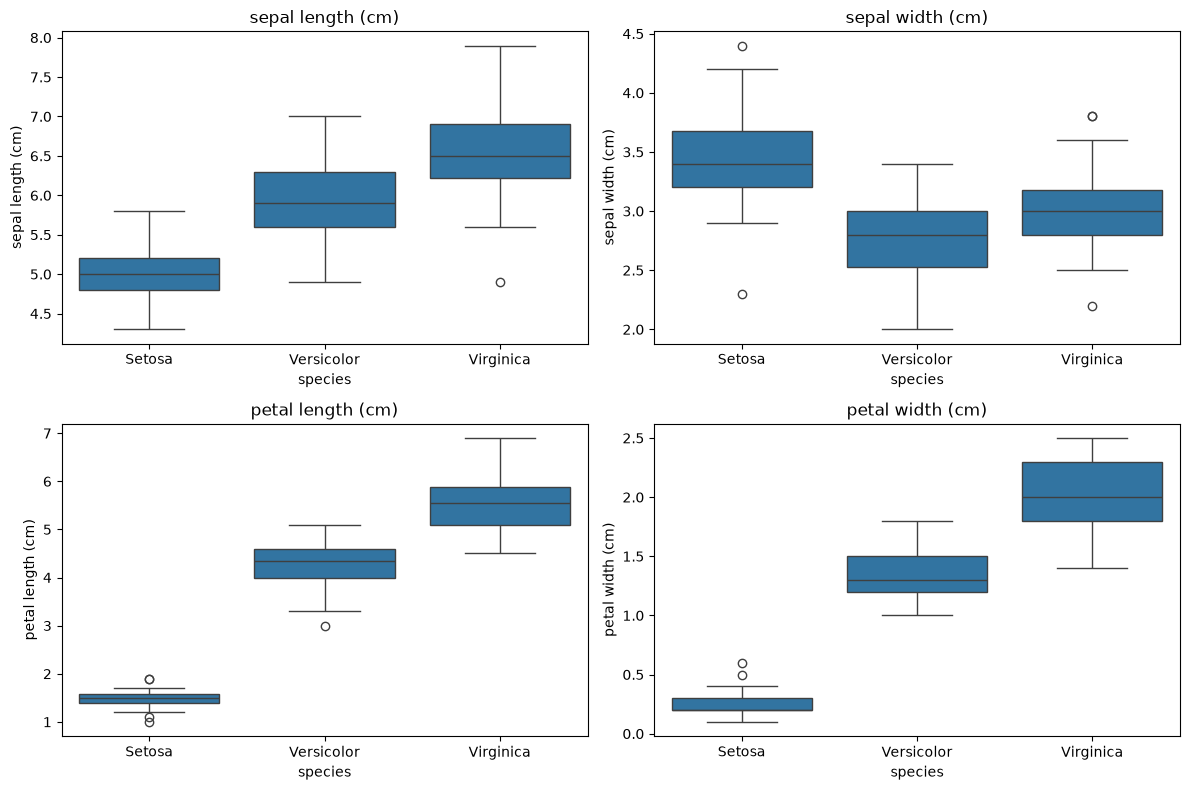

In [43]:
# Box plots for each numerical feature

features = iris.feature_names

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features):
    plt.subplot(2, 2, i + 1)

    sns.boxplot(
        data=df,
        x="species",
        y=feature
    )

    plt.title(feature)

plt.tight_layout()
plt.show()

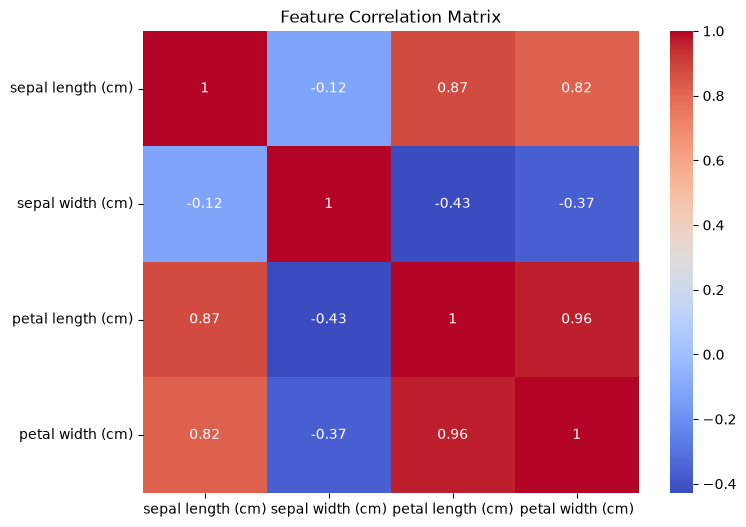

In [44]:
# Correlation heatmap for numerical features

correlation = df[iris.feature_names].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

# 3. Feature Selection Discussion

Based on the pairplot and box plots, petal length and petal width appear to be the most discriminative features.

These features show clearer separation between Setosa, Versicolor, and Virginica compared with the sepal measurements.

However, all four features are retained for model training because each feature provides useful information for classification.

# 4. Train/Test Split

The dataset is divided into training and testing sets. 80% of the data is used to train the models, while 20% is reserved for evaluating their performance on unseen data.

In [45]:
# Separate features (X) and target (y)

X = df[iris.feature_names]

y = df["species"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target:


0    Setosa
1    Setosa
2    Setosa
3    Setosa
4    Setosa
Name: species, dtype: str

In [46]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


# 5. Machine Learning Model Training

Three classification algorithms are trained and compared:

1. Logistic Regression
2. K-Nearest Neighbors
3. Random Forest

In [47]:
# Import classification algorithms

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [48]:
# Create the classification models

logistic_model = LogisticRegression(
    max_iter=200
)

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [49]:
# Train the models

logistic_model.fit(X_train, y_train)

knn_model.fit(X_train, y_train)

random_forest_model.fit(X_train, y_train)

print("All models trained successfully!")

All models trained successfully!


# 6. Model Evaluation

The trained models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

In [50]:
# Evaluate Logistic Regression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

logistic_predictions = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print("Logistic Regression Accuracy:",
      logistic_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        logistic_predictions
    )
)

Logistic Regression Accuracy: 0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      0.90      0.95        10
   Virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



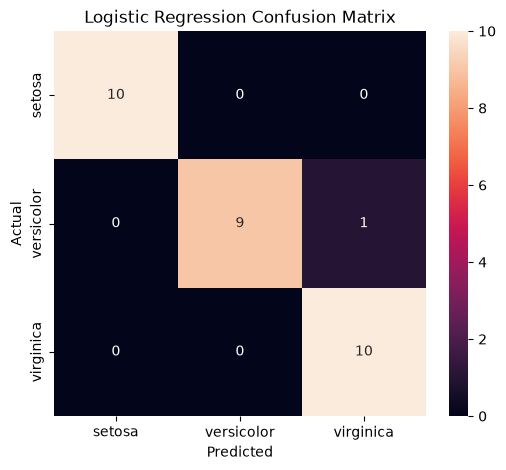

In [51]:
# Confusion Matrix - Logistic Regression

cm = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [52]:
# Evaluate K-Nearest Neighbors

knn_predictions = knn_model.predict(X_test)

knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

print("KNN Accuracy:",
      knn_accuracy)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        knn_predictions
    )
)

KNN Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10
   Virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



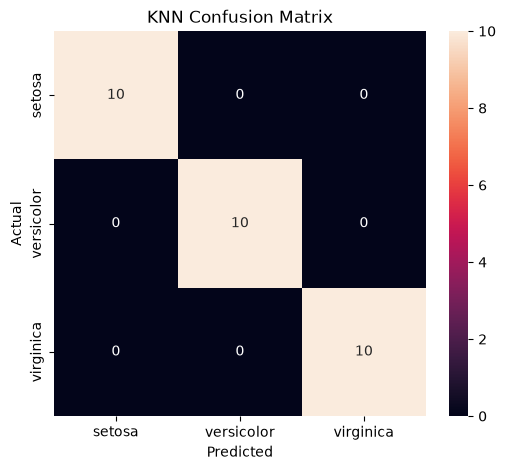

In [53]:
# Confusion Matrix - KNN

cm = confusion_matrix(
    y_test,
    knn_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

In [54]:
# Evaluate Random Forest

rf_predictions = random_forest_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Random Forest Accuracy:",
      rf_accuracy)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        rf_predictions
    )
)

Random Forest Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.82      0.90      0.86        10
   Virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



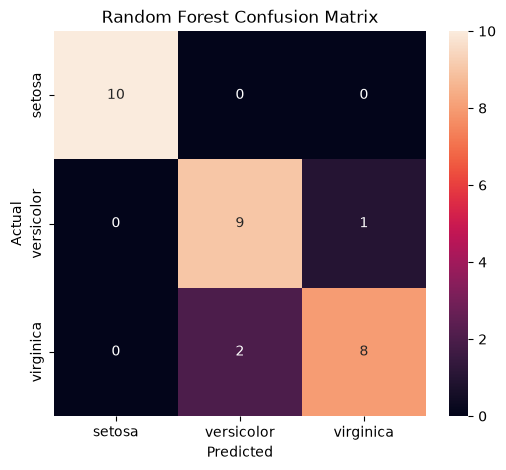

In [55]:
# Confusion Matrix - Random Forest

cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

# 7. Model Comparison

In [56]:
# Compare the accuracy of all models

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy,
        rf_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.966667
1,K-Nearest Neighbors,1.000000
2,Random Forest,0.900000


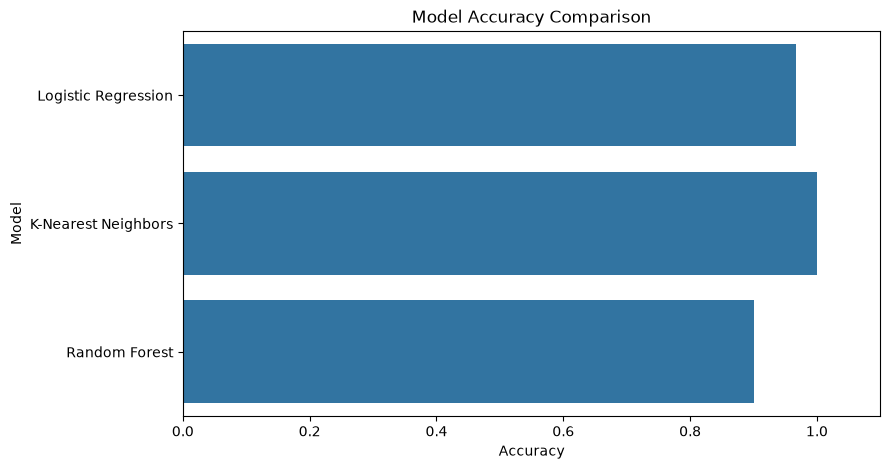

In [57]:
# Visualize model accuracy comparison

plt.figure(figsize=(9, 5))

sns.barplot(
    data=results,
    x="Accuracy",
    y="Model"
)

plt.xlim(0, 1.1)

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.show()

In [58]:
# Identify the best-performing model

best_model_row = results.loc[
    results["Accuracy"].idxmax()
]

best_model_name = best_model_row["Model"]
best_accuracy = best_model_row["Accuracy"]

print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

Best Model: K-Nearest Neighbors
Best Accuracy: 1.0


# Identify the best-performing model

best_model_row = results.loc[
    results["Accuracy"].idxmax()
]

best_model_name = best_model_row["Model"]
best_accuracy = best_model_row["Accuracy"]

print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

In [59]:
# Select the best model

if best_model_name == "Logistic Regression":
    best_model = logistic_model

elif best_model_name == "K-Nearest Neighbors":
    best_model = knn_model

else:
    best_model = random_forest_model

print("Selected model:", best_model_name)

Selected model: K-Nearest Neighbors


In [60]:
# Save the best-performing model

import joblib

joblib.dump(
    best_model,
    "iris_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [61]:
# Load the saved model

loaded_model = joblib.load(
    "iris_model.pkl"
)



In [ ]:
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=iris.feature_names
)

prediction = loaded_model.predict(new_flower)

print("Predicted species:", prediction[0])

Predicted species: Setosa


# 9. Conclusion

In this project, machine learning classification techniques were used to predict iris flower species based on sepal length, sepal width, petal length, and petal width.

Exploratory Data Analysis showed that the dataset contains 150 samples and does not contain missing values. The visualizations indicated that petal length and petal width are particularly useful for distinguishing between the three species.

Three classification models—Logistic Regression, K-Nearest Neighbors, and Random Forest—were trained and evaluated.

The models were compared using accuracy, precision, recall, F1-score, and confusion matrices. The model with the highest test accuracy was selected as the final model.

The selected model was saved using Joblib and tested on a new flower measurement.

This project demonstrates a complete machine learning classification workflow, from data exploration and visualization to model training, evaluation, comparison, and model saving.